In [1]:
# Autoreload imported modules when running a cell so we don't have to
# restart the notebook as often
%load_ext autoreload
%autoreload 2
# Display plots in an interactive way. widget works well with vscode
%matplotlib widget

In [2]:
import ipywidgets as widgets  # pyright: ignore[reportMissingTypeStubs]
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from simulations.envelope import (
    TIME_END,
    TIME_MIDPOINT,
    TIME_START,
    EnvelopeSettings,
    a_d_envelope,
)


def settings_label(s: EnvelopeSettings) -> str:
    return f"a={s.attack}, d={s.decay}, s={s.shape}, amp={s.amplitude}"


TIMES = np.linspace(TIME_MIDPOINT, TIME_MIDPOINT + (TIME_END - TIME_START) * 2.7, 1000)

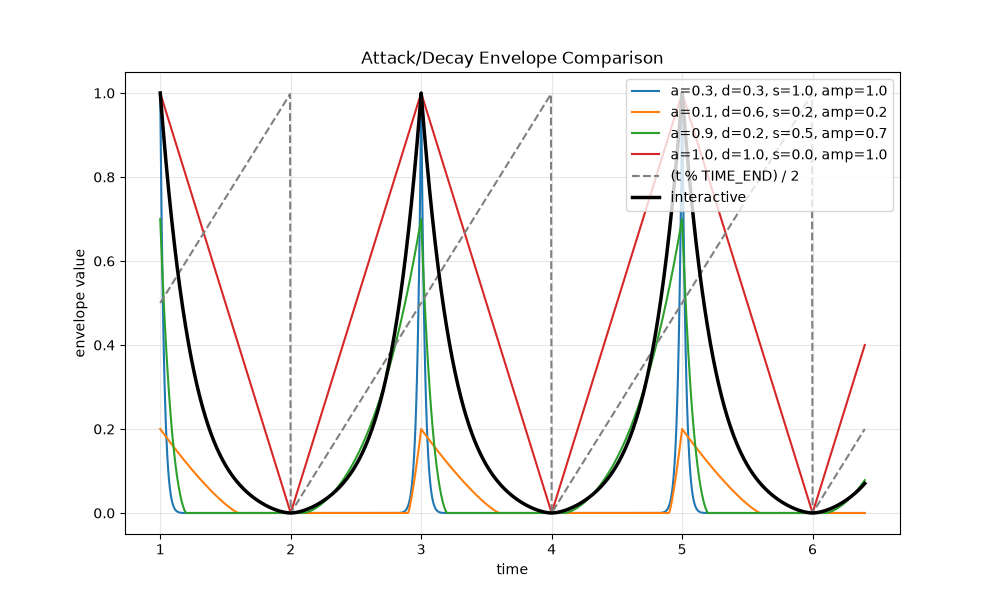

In [3]:
# Show how a single envelope is synthesized and how the position of its peak does not depend on its input parameters
fixed_envelopes = [
    EnvelopeSettings(attack=0.3, decay=0.3, shape=1.0, amplitude=1.0),
    EnvelopeSettings(attack=0.1, decay=0.6, shape=0.2, amplitude=0.2),
    EnvelopeSettings(attack=0.9, decay=0.2, shape=0.5, amplitude=0.7),
    EnvelopeSettings(attack=1.0, decay=1.0, shape=0.0, amplitude=1.0),
]

fig, ax = plt.subplots(figsize=(10, 6))

fixed_lines: list[Line2D] = []
for envelope in fixed_envelopes:
    values = [a_d_envelope(envelope, t % TIME_END) for t in TIMES]
    (line,) = ax.plot(TIMES, values, label=settings_label(envelope))
    fixed_lines.append(line)

# Reference line: (t % TIME_END) / 2
(ref_line,) = ax.plot(
    TIMES,
    [(t % TIME_END) / 2 for t in TIMES],
    label="(t % TIME_END) / 2",
    linestyle="--",
    color="gray",
)

# Interactive envelope
interactive_settings = EnvelopeSettings(attack=1.0, decay=1.0, shape=0.7, amplitude=1.0)
interactive_values = [a_d_envelope(interactive_settings, t % TIME_END) for t in TIMES]
(interactive_line,) = ax.plot(
    TIMES, interactive_values, label="interactive", linewidth=2.5, color="black"
)


ax.set_xlabel("time")
ax.set_ylabel("envelope value")
ax.set_title("Attack/Decay Envelope Comparison")
ax.legend(loc="upper right")
ax.grid(visible=True, alpha=0.3)

# Widgets
attack_slider = widgets.FloatSlider(
    value=interactive_settings.attack,
    min=0.01,
    max=1.0,
    step=0.01,
    description="attack",
)
decay_slider = widgets.FloatSlider(
    value=interactive_settings.decay, min=0.01, max=1.0, step=0.01, description="decay"
)
shape_slider = widgets.FloatSlider(
    value=interactive_settings.shape, min=0.01, max=1.0, step=0.01, description="shape"
)
amp_slider = widgets.FloatSlider(
    value=interactive_settings.amplitude,
    min=0.01,
    max=1.0,
    step=0.01,
    description="amplitude",
)
fixed_checkbox = widgets.Checkbox(value=True, description="fixed envelopes")


# Callbacks
def update_interactive_line(*_):
    settings = EnvelopeSettings(
        attack=attack_slider.value,
        decay=decay_slider.value,
        shape=shape_slider.value,
        amplitude=amp_slider.value,
    )
    values = [a_d_envelope(settings, t % TIME_END) for t in TIMES]
    interactive_line.set_ydata(values)
    fig.canvas.draw_idle()


def update_fixed_visibility(change: dict[str, bool]):
    for line in fixed_lines:
        line.set_visible(change["new"])
    fig.canvas.draw_idle()


# Hook up interactive inputs changes
for slider in (attack_slider, decay_slider, shape_slider, amp_slider):
    slider.observe(update_interactive_line, names="value")
fixed_checkbox.observe(update_fixed_visibility, names="value")

# Layout
controls = widgets.HBox(
    [
        widgets.VBox(
            [
                attack_slider,
                decay_slider,
                shape_slider,
                amp_slider,
            ]
        ),
        fixed_checkbox,
    ]
)

display(controls)

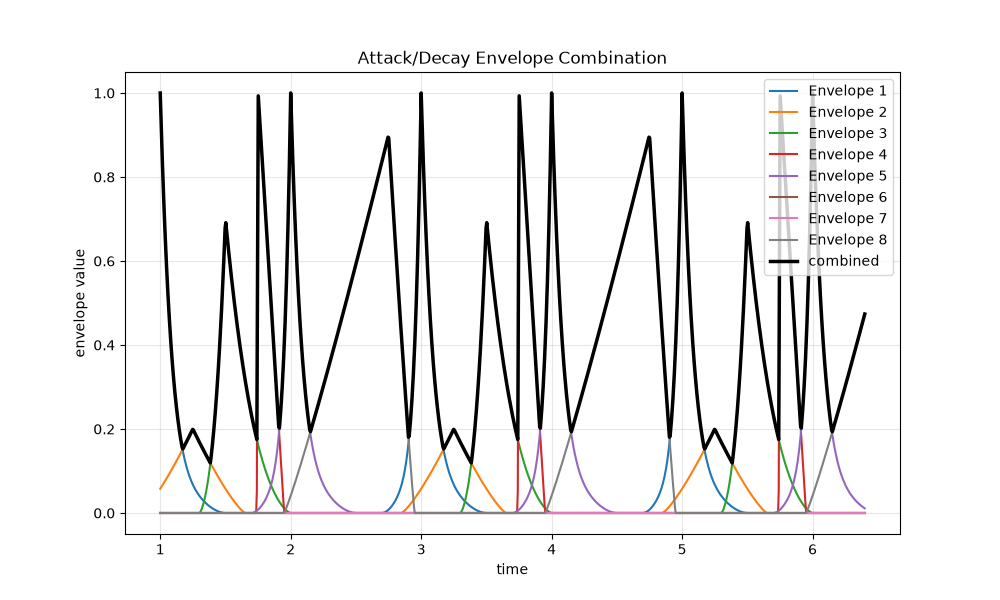

In [4]:
# Show how multiple envelopes are generated and combined
from dataclasses import asdict
from typing import cast

from simulations.combiners import CombineFn, combine_interpolate_linear, combine_max
from simulations.compute import compute_values as _compute_values

# Initial envelope settings
envelopes = [
    EnvelopeSettings(attack=0.3, decay=0.5, shape=0.8, amplitude=1.0),
    EnvelopeSettings(attack=0.4, decay=0.4, shape=0.2, amplitude=0.2),
    EnvelopeSettings(attack=0.2, decay=0.5, shape=0.5, amplitude=0.7),
    EnvelopeSettings(attack=0.01, decay=0.2, shape=0.0, amplitude=1.0),
    EnvelopeSettings(attack=0.3, decay=0.5, shape=0.8, amplitude=1.0),
    EnvelopeSettings(attack=0.4, decay=0.4, shape=0.2, amplitude=0.0),
    EnvelopeSettings(attack=0.2, decay=0.5, shape=0.5, amplitude=0.0),
    EnvelopeSettings(attack=0.8, decay=0.2, shape=0.1, amplitude=0.9),
]
interval = 0.25

combine_fns: dict[str, CombineFn] = {
    "max": combine_max,
    "linear": combine_interpolate_linear,
}


def compute_values(envelopes: list[EnvelopeSettings], combine_fn: CombineFn):
    return _compute_values(envelopes, interval, list(TIMES), combine_fn)


# --- Build sliders for each envelope ---
slider_groups: list[dict[str, widgets.FloatSlider]] = []

n_envelopes = len(envelopes)
param_names = list(asdict(envelopes[0]).keys())
col_width = "140px"

# Build all sliders first, grouped by envelope (so slider_groups stays the same shape)
for env in envelopes:
    group = {
        param: widgets.FloatSlider(
            value=getattr(env, param),
            min=0.01,
            max=1.0,
            step=0.01,
            description="",
            layout=widgets.Layout(width=col_width),
        )
        for param in param_names
    }
    slider_groups.append(group)

# Now lay them out row-by-row (param) / column-by-column (envelope) in a GridBox
grid_children: list[widgets.Label | widgets.FloatSlider] = [
    widgets.Label("")
]  # top-left empty corner
grid_children += [widgets.Label(f"Envelope {i + 1}") for i in range(n_envelopes)]

for param in param_names:
    grid_children.append(widgets.Label(param))
    for group in slider_groups:
        grid_children.append(group[param])

sliders_grid = widgets.GridBox(
    children=grid_children,
    layout=widgets.Layout(
        grid_template_columns=f"4em {' '.join([col_width] * n_envelopes)}",
        grid_template_rows="auto",
        grid_gap="4px 10px",
        align_items="center",
    ),
)

# --- Radio buttons for combine mode ---
combine_mode_radio = widgets.RadioButtons(
    options=list(combine_fns.keys()),
    value="max",
    description="combine:",
)


def current_envelopes():
    return [
        EnvelopeSettings(
            attack=g["attack"].value,
            decay=g["decay"].value,
            shape=g["shape"].value,
            amplitude=g["amplitude"].value,
        )
        for g in slider_groups
    ]


# --- Create the figure once ---
plt.figure(figsize=(10, 6))
ax = plt.gca()

initial_envelopes = current_envelopes()
initial_samples_per_envelope, initial_values_combined = compute_values(
    initial_envelopes, combine_fns[cast("str", combine_mode_radio.value)]
)

envelope_lines: list[Line2D] = []
for i, samples in enumerate(initial_samples_per_envelope):
    (line,) = ax.plot(TIMES, [s.value for s in samples], label=f"Envelope {i + 1}")
    envelope_lines.append(line)

(combined_line,) = ax.plot(
    TIMES, initial_values_combined, label="combined", color="black", linewidth=2.5
)

ax.set_xlabel("time")
ax.set_ylabel("envelope value")
ax.set_title("Attack/Decay Envelope Combination")
legend = ax.legend(loc="upper right")
ax.grid(visible=True, alpha=0.3)


def redraw(*_):
    envelopes = current_envelopes()
    combine_fn = combine_fns[cast("str", combine_mode_radio.value)]

    samples_per_envelope, values_combined = compute_values(envelopes, combine_fn)

    for line, samples in zip(envelope_lines, samples_per_envelope, strict=True):
        line.set_ydata([s.value for s in samples])

    combined_line.set_ydata(values_combined)

    # Legend labels potentially changed, so refresh it
    ax.legend(loc="upper right")
    ax.figure.canvas.draw_idle()


# Wire up observers
for g in slider_groups:
    for slider in g.values():
        slider.observe(redraw, names="value")

combine_mode_radio.observe(redraw, names="value")

# Layout
display(
    widgets.VBox(
        [
            sliders_grid,
            combine_mode_radio,
        ]
    )
)